**Построить многоклассовый классификатор для определения вида ирисов по
двум признакам (длина и ширина чашелистика), проанализировать отступы
объектов и преобразовать дискриминантные функции в вероятности с помощью
SoftMax.**


In [19]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report, confusion_matrix 
import seaborn as sns 


iris = load_iris()

X = iris.data[: , :2]
y = iris.target

X_train , X_test, y_train , y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


model = LogisticRegression(multi_class = 'multinomial' , max_iter = 1000)

model.fit(X_train , y_train)



y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print('Classification Report:') 
print(classification_report(y_test, y_pred, target_names = iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.78      0.54      0.64        13
   virginica       0.65      0.85      0.73        13

    accuracy                           0.82        45
   macro avg       0.81      0.79      0.79        45
weighted avg       0.83      0.82      0.82        45



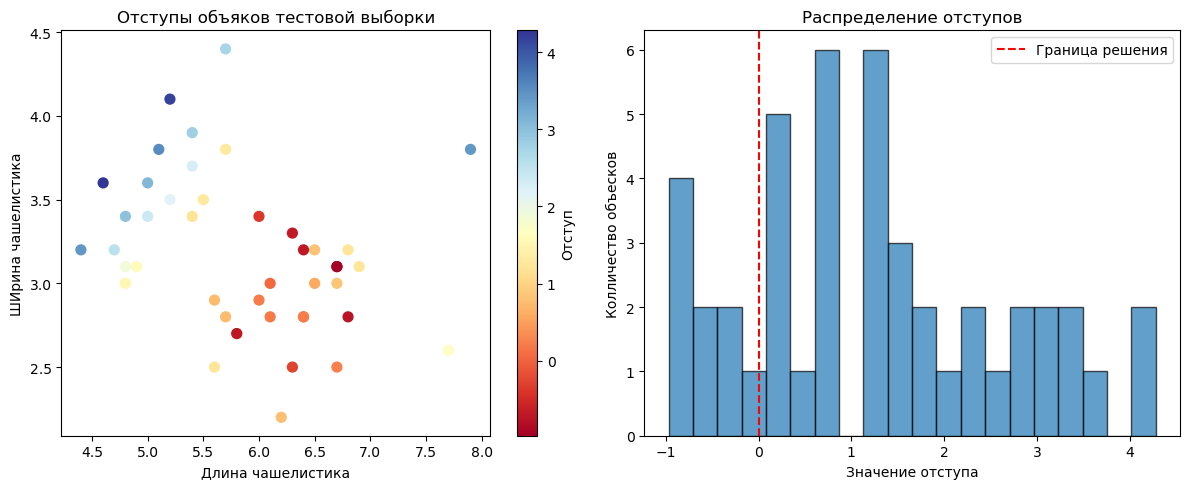

In [35]:

def compute_margin(x, true_class, model): 

    logits = model.decision_function([x])[0]
    true_logit = logits[true_class]
    other_logits = np.delete(logits, true_class)
    max_other = np.max(other_logits)
    return true_logit - max_other


margin = [compute_margin(X_test[i], y_test[i], model) for i in range(len(X_test))]

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
scatter = plt.scatter(X_test[:,0], X_test[:,1], c= margin, cmap = 'RdYlBu', s = 50)
plt.colorbar(scatter, label= 'Отступ')
plt.xlabel('Длина чашелистика')
plt.ylabel('ШИрина чашелистика')
plt.title('Отступы объяков тестовой выборки')

plt.subplot(1,2,2)
plt.hist(margin, bins = 20, alpha = 0.7 , edgecolor = 'black')
plt.axvline(x =0, color ='red', linestyle = '--', label = 'Граница решения')
plt.xlabel('Значение отступа')
plt.ylabel('Колличество объесков')
plt.title('Распределение отступов')
plt.legend()

plt.tight_layout()
plt.show()




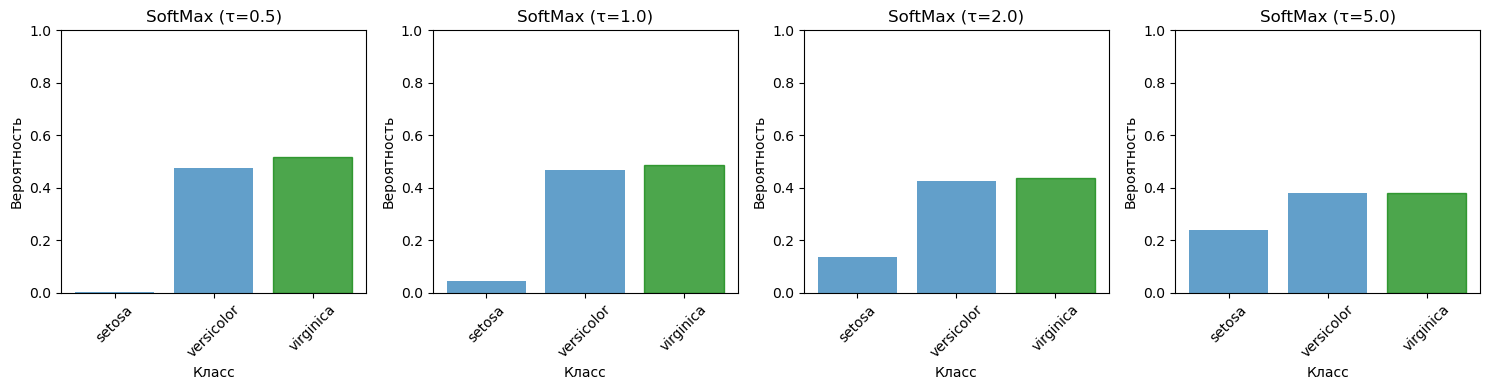


Объект с координатами: [6.1 3. ]
Истинный класс: virginica
Логиты: [-1.55084957  0.75404904  0.79680053]


In [41]:
def softmax(z , tau = 1.0):
    z = z/tau
    e_z = np.exp(z - np.max(z))
    return e_z / np.sum(e_z)


complex_sample_idx = np.argmin(np.abs(margin))
complex_sample = X_test[complex_sample_idx]
true_class = y_test[complex_sample_idx]

logits = model.decision_function([complex_sample])[0]


tau = [ 0.5, 1.0, 2.0 ,5.0]
probabilities = {}

for temp in tau:
    probabilities[temp] = softmax(logits, temp)



plt.figure(figsize=(15, 4))
for i, temp in enumerate(tau, 1):
    plt.subplot(1, 4, i)
    bars = plt.bar(range(3), probabilities[temp], alpha=0.7)
    bars[true_class].set_color('green')
    plt.ylim(0, 1)
    plt.title(f'SoftMax (τ={temp})')
    plt.xlabel('Класс')
    plt.ylabel('Вероятность')
    plt.xticks(range(3), iris.target_names, rotation=45)

plt.tight_layout()
plt.show()
print(f"\nОбъект с координатами: {complex_sample}")
print(f"Истинный класс: {iris.target_names[true_class]}")
print(f"Логиты: {logits}")